# Final Model -- ResNet50 (frozen) + MLP head

The final model chosen after the experiments in `Basic_CNN_model.ipynb`: a frozen ImageNet **ResNet50**
backbone with a small **MLP head** (2048 → 128 → 32 → 1), using the best settings found by the grid search
there.

**Images:** hair-removed **lesion crops with a 10% margin** (`train_cropped_margin_0.10`, made by
`Crop_margin_ablation.ipynb`).

**Data split** (shared with the metadata and fusion models):

| Split | Used here for |
|---|---|
| `training_set.csv` | everything the image model learns from: 5-fold CV, threshold, final training |
| `validation_set.csv` | **never seen during training** -- the final model only predicts probabilities on it, which become training data for the fusion model |
| test set (later) | completely held out; scored once at the end |

**Pipeline:**

1. **5-fold patient-grouped cross-validation** on the training set. Each fold's model trains on 4/5 of the
   patients and is early-stopped on the 5th fold (its val fold), then predicts that val fold. These
   out-of-fold predictions give an honest training-set performance estimate.
2. The **final model** is trained on the whole training set.
3. The **decision threshold** is picked on the final model's predictions on `validation_set.csv`: the highest
   threshold that still gives **sensitivity >= 0.85**. Same model, same probability scale.

**Outputs:** CSVs of `image_name` + `probability` for the validation set (fusion-model input), the
training set (out-of-fold), and later the test set. The threshold is saved separately in
`final_resnet_config.json` so the image-only model can be compared with the metadata and fusion models.

In [35]:
import os
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix every source of randomness up front so results are reproducible run-to-run --
# TensorFlow's own RNG (weight init) and GPU op-level determinism need pinning
# separately from numpy/sklearn: cuDNN picks nondeterministic algorithms by default.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

: 

: 

## (Colab only) Unpack data from Google Drive

On a **Colab kernel**, upload `melanoma_data.zip` to your Google Drive once; this cell mounts Drive and
unzips it into `/content` each session (falls back to a directly-uploaded `/content/melanoma_data.zip`).
No-op locally.

In [36]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip -- "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

data ready in /content


: 

: 

In [37]:
# VS Code's Jupyter extension can run this notebook with the *workspace root* as the
# working directory, which breaks every relative path below -- hop into this notebook's
# own folder if we're not already there (and not on Colab, which uses /content).
import os

_nb_path = globals().get('__vsc_ipynb_file__')
if _nb_path and not os.path.isdir('/content'):
    os.chdir(os.path.dirname(_nb_path))

print('working directory:', os.getcwd())

working directory: /content


: 

: 

## Labels

In [38]:
import pandas as pd

TRAIN_DIR = 'train'

# sorted() so image order (and so every fold split) is identical across machines/runs
train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})
labels_df = pd.read_csv('train_labels.csv')
image_df = files_df.merge(labels_df, on='image_name', how='inner')[['image_name', 'patient_id', 'image_path', 'target']]

print(f'{len(image_df)} labelled images, {image_df["patient_id"].nunique()} patients, '
      f'{int(image_df["target"].sum())} malignant ({image_df["target"].mean():.2%})')

6864 labelled images, 422 patients, 128 malignant (1.86%)


: 

: 

### Training / validation split files

`training_set.csv` / `validation_set.csv` list `image_name` only -- the shared, pre-defined, patient-grouped
split used by all three models. On Colab they aren't in `melanoma_data.zip`, so this reuses a copy from Drive
if there is one, otherwise prompts an upload.

In [39]:
import shutil

SPLIT_FILES = ['training_set.csv', 'validation_set.csv']
DRIVE_SPLIT_DIR = '/content/drive/MyDrive'  # adjust if you put them elsewhere in Drive

if os.path.isdir('/content'):
    for f in SPLIT_FILES:
        if not os.path.exists(f) and os.path.exists(os.path.join(DRIVE_SPLIT_DIR, f)):
            shutil.copy(os.path.join(DRIVE_SPLIT_DIR, f), f)
            print(f'copied {f} from Google Drive')
    still_missing = [f for f in SPLIT_FILES if not os.path.exists(f)]
    if still_missing:
        print(f'upload {still_missing} now (or drop copies into {DRIVE_SPLIT_DIR} and re-run this cell):')
        from google.colab import files
        files.upload()

: 

: 

In [40]:
train_df = image_df.merge(pd.read_csv('training_set.csv'), on='image_name', how='inner').reset_index(drop=True)
val_df = image_df.merge(pd.read_csv('validation_set.csv'), on='image_name', how='inner').reset_index(drop=True)

assert len(train_df) == len(pd.read_csv('training_set.csv')), 'some training_set.csv image_names not found'
assert len(val_df) == len(pd.read_csv('validation_set.csv')), 'some validation_set.csv image_names not found'
assert not (set(train_df['patient_id']) & set(val_df['patient_id'])), 'patient leakage between training/validation!'

for name, df in [('training', train_df), ('validation', val_df)]:
    print(f'{name:10s}: {len(df)} images, {df["patient_id"].nunique()} patients, '
          f'benign={int((df["target"] == 0).sum())}, malignant={int(df["target"].sum())}')

training  : 5629 images, 337 patients, benign=5526, malignant=103
validation: 1235 images, 85 patients, benign=1210, malignant=25


: 

: 

## Cropped images (10% margin)

Restores `train_cropped_margin_0.10/` from `melanoma_cropped_margin_0.10.zip` (local, then Drive). These
crops are generated by `Crop_margin_ablation.ipynb` -- run that first if no zip exists yet.

In [41]:
import zipfile

IMG_SIZE = 224
CROP_MARGIN = 0.10
CROPPED_DIR = 'train_cropped_margin_0.10'
CROPPED_ZIP = 'melanoma_cropped_margin_0.10.zip'
DRIVE_CROPPED_ZIP = '/content/drive/MyDrive/melanoma_cropped_margin_0.10.zip'

if not os.path.isdir(CROPPED_DIR) or not os.listdir(CROPPED_DIR):
    if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')
    cached_zip = next((z for z in (CROPPED_ZIP, DRIVE_CROPPED_ZIP) if os.path.exists(z)), None)
    if cached_zip is None:
        raise FileNotFoundError(
            f'{CROPPED_DIR}/ not found and no {CROPPED_ZIP} locally or at {DRIVE_CROPPED_ZIP} -- '
            'run Crop_margin_ablation.ipynb first to generate the 10%-margin crops')
    os.makedirs(CROPPED_DIR, exist_ok=True)
    get_ipython().system(f'unzip -q "{cached_zip}" -d "{CROPPED_DIR}"')
    print(f'restored crops from {cached_zip}')

# Every labelled image needs a same-filename crop (junk like .DS_Store / __MACOSX is ignored)
crop_files = {f for f in os.listdir(CROPPED_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
missing = sorted({os.path.basename(p) for p in image_df['image_path']} - crop_files)
assert not missing, f'{len(missing)} images have no crop in {CROPPED_DIR}/, e.g. {missing[:5]}'
print(f'{len(crop_files)} crops in {CROPPED_DIR}/ -- every labelled image covered')

6864 crops in train_cropped_margin_0.10/ -- every labelled image covered


: 

: 

In [42]:
def load_images(paths, image_dir, img_size=IMG_SIZE):
    """Loads the same-filename image from image_dir for every path, as uint8 RGB."""
    X = np.empty((len(paths), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(paths):
        with Image.open(os.path.join(image_dir, os.path.basename(path))) as img:
            X[i] = np.array(img.convert('RGB').resize((img_size, img_size)))
    return X

: 

: 

In [43]:
# Training set: everything the image model learns from
X = load_images(train_df['image_path'], CROPPED_DIR)
y = train_df['target'].to_numpy().astype(int)
groups = train_df['patient_id'].to_numpy()

# Validation set: only ever predicted on, by the final model (fusion-model input)
X_val = load_images(val_df['image_path'], CROPPED_DIR)

print('training:  ', X.shape, f'{X.nbytes / 1e6:.0f} MB')
print('validation:', X_val.shape, f'{X_val.nbytes / 1e6:.0f} MB')

training:   (5629, 224, 224, 3) 847 MB
validation: (1235, 224, 224, 3) 186 MB


: 

: 

## Augmentation

Same `melanoma_augment` recipe as `Basic_CNN_model.ipynb`: no hue/saturation shifts (pigment colour is
diagnostic), mirrored borders instead of black wedges, no zoom/warp (images are already cropped to the
lesion), and a small CoarseDropout box. Applied **online** to oversampled malignant images only -- a fresh
random transform every epoch.

In [44]:
import albumentations as A
import cv2

melanoma_augment = A.Compose([
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(std_range=(0.02, 0.08)),
    ], p=0.7),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=15,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.85),
    A.CoarseDropout(num_holes_range=(1, 1),
                     hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2),
                     p=0.5),
])

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


: 

: 

## Model: ResNet50 (frozen) + MLP head -- current best settings

`Dropout(0.4)` → `Dense(128, relu)` → `Dropout(0.6)` → `Dense(32, relu)` → `Dropout(0.4)` → `Dense(1, sigmoid)`,
L2 = 1e-3 on every Dense kernel, Adam at 5e-4, batch size 32. Malignant images are oversampled (with fresh
augmentation) to a 70/30 benign/malignant mix, and the loss uses fully 'balanced' class weights computed at
that mix.

Images go in as raw RGB 0-255 and are normalised **once**, inside the data pipeline, by ResNet50's own
`preprocess_input` (RGB→BGR + ImageNet mean subtraction).

In [45]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from sklearn.utils.class_weight import compute_class_weight

# Best settings from the ResNet50 + MLP grid search in Basic_CNN_model.ipynb
MLP_HIDDEN_UNITS = [128, 32]
INPUT_DROPOUT_RATE = 0.4          # 'high' dropout preset -- on the frozen ResNet50 features
MLP_DROPOUT_RATES = [0.6, 0.4]    # 'high' dropout preset -- after each hidden layer
L2_STRENGTH = 1e-3
LEARNING_RATE = 5e-4
BATCH_SIZE = 32
TARGET_MINORITY_RATIO = 0.3       # oversample malignant to a 70/30 benign/malignant mix
CLASS_WEIGHT_BLEND = 1.0          # 1.0 = fully 'balanced' class weights
MAX_EPOCHS = 20
PATIENCE = 5


def make_resnet_dataset(images, labels=None, batch_size=BATCH_SIZE):
    """Streams uint8 images through ResNet50's preprocess_input in batches (converting the whole
    array to float32 up front would need several GB)."""
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(images)
        prep = lambda x: resnet_preprocess_input(tf.cast(x, tf.float32))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        prep = lambda x, lbl: (resnet_preprocess_input(tf.cast(x, tf.float32)), lbl)
    return ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def augment_and_preprocess(image, label):
    def _augment(img):
        return melanoma_augment(image=img.numpy())['image']
    augmented = tf.py_function(_augment, [image], tf.uint8)
    augmented.set_shape(image.shape)
    return resnet_preprocess_input(tf.cast(augmented, tf.float32)), label


def n_oversampled(labels, ratio=TARGET_MINORITY_RATIO):
    """(n_benign, n_malignant after oversampling) for a training set."""
    n_benign, n_mal = int((labels == 0).sum()), int((labels == 1).sum())
    return n_benign, max(n_mal, int(round(n_benign * ratio / (1 - ratio))))


def make_training_dataset(images, labels, seed, ratio=TARGET_MINORITY_RATIO, batch_size=BATCH_SIZE):
    """Originals (un-augmented) + malignant images oversampled by index to `ratio`; each oversampled
    copy gets a fresh random melanoma_augment transform every epoch."""
    rng = np.random.default_rng(seed)
    minority_idx = np.where(labels == 1)[0]
    _, n_target = n_oversampled(labels, ratio)
    extra_idx = rng.choice(minority_idx, size=n_target - len(minority_idx), replace=True)

    base_ds = tf.data.Dataset.from_tensor_slices((images, labels)).map(
        lambda img, lbl: (resnet_preprocess_input(tf.cast(img, tf.float32)), lbl),
        num_parallel_calls=tf.data.AUTOTUNE)
    extra_ds = tf.data.Dataset.from_tensor_slices((images[extra_idx], labels[extra_idx])).map(
        augment_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = base_ds.concatenate(extra_ds).shuffle(len(images) + len(extra_idx), seed=seed,
                                               reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def blended_class_weight(labels, ratio=TARGET_MINORITY_RATIO, blend=CLASS_WEIGHT_BLEND):
    """'balanced' class weights computed at the post-oversampling mix, blended toward 1.0."""
    n_benign, n_mal = n_oversampled(labels, ratio)
    mix = np.concatenate([np.zeros(n_benign, dtype=int), np.ones(n_mal, dtype=int)])
    weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=mix)
    return {k: 1.0 + blend * (w - 1.0) for k, w in enumerate(weights)}


def build_resnet_mlp():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False  # frozen backbone -- only the MLP head trains

    reg = lambda: tf.keras.regularizers.l2(L2_STRENGTH)
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dropout(INPUT_DROPOUT_RATE)(x)
    for units, rate in zip(MLP_HIDDEN_UNITS, MLP_DROPOUT_RATES):
        x = layers.Dense(units, activation='relu', kernel_regularizer=reg())(x)
        x = layers.Dropout(rate)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=reg())(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
    )
    return model


def plot_training_history(history, title, metrics=('loss', 'auc', 'precision', 'recall')):
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.5 * len(metrics), 3.6))
    for ax, metric in zip(axes, metrics):
        ax.plot(history.history[metric], label='train')
        if f'val_{metric}' in history.history:
            ax.plot(history.history[f'val_{metric}'], label='val')
        ax.set_title(metric)
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


print('class weights at the 70/30 mix (training set):', blended_class_weight(y))

class weights at the 70/30 mix (training set): {0: np.float64(0.7142598624683315), 1: np.float64(1.6668074324324325)}


: 

: 

## 5-fold patient-grouped cross-validation (training set only)

`StratifiedGroupKFold` keeps each patient's images in a single fold, with a similar malignant rate in each
fold. Each fold is a plain train/val split:

| Part | Share of the training set | Used for |
|---|---|---|
| **train** | 80% (4 folds) | training the head |
| **val** | 20% (1 fold) | early stopping (patience 5, reverts to the epoch with the best val AUC), then the out-of-fold predictions |

Every training image ends up in exactly one val fold, so the pooled out-of-fold predictions cover the whole
training set. Because each val fold also picks its model's best epoch, its predictions are very slightly
optimistic. That's a deliberate trade for training each fold on 80% instead of 64%.

In [46]:
from sklearn.model_selection import StratifiedGroupKFold

N_FOLDS = 5
splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

folds = []
for fold, (train_idx, val_idx) in enumerate(splitter.split(train_df, y, groups=groups), start=1):
    assert not (set(groups[train_idx]) & set(groups[val_idx])), f'fold {fold}: patient leakage'
    folds.append({'fold': fold, 'train': train_idx, 'val': val_idx})
    print(f'fold {fold}: train {len(train_idx)} ({y[train_idx].sum()} mal) | val {len(val_idx)} ({y[val_idx].sum()} mal)')

all_val = np.concatenate([f['val'] for f in folds])
assert len(all_val) == len(y) and len(set(all_val)) == len(y), 'val folds must cover every training image once'

fold 1: train 4441 (84 mal) | val 1188 (19 mal)
fold 2: train 4403 (81 mal) | val 1226 (22 mal)
fold 3: train 4621 (84 mal) | val 1008 (19 mal)
fold 4: train 4573 (77 mal) | val 1056 (26 mal)
fold 5: train 4478 (86 mal) | val 1151 (17 mal)


: 

: 

### Train one model per fold

Each fold trains a fresh model (on a GPU, roughly a few minutes per fold), then predicts its val fold.
Results are saved after every fold to `final_resnet_trainset_oof_cv.csv` and `final_resnet_trainset_fold_summary.csv`
(copied to Drive on Colab), so if the runtime disconnects, re-running this cell skips the folds that are
already done. Delete both CSVs to start over (e.g. after changing any setting above).

In [47]:
from sklearn.metrics import roc_auc_score

OOF_CSV = 'final_resnet_trainset_oof_cv.csv'
FOLD_CSV = 'final_resnet_trainset_fold_summary.csv'
DRIVE_DIR = '/content/drive/MyDrive'


def load_csv(name):
    path = next((p for p in (name, os.path.join(DRIVE_DIR, name)) if os.path.exists(p)), None)
    return pd.read_csv(path) if path else None


def save_csv(df, name):
    df.to_csv(name, index=False)
    if os.path.isdir(DRIVE_DIR):
        shutil.copy(name, os.path.join(DRIVE_DIR, name))


oof_df = load_csv(OOF_CSV)
fold_summary = load_csv(FOLD_CSV)
oof_df = oof_df if oof_df is not None else pd.DataFrame()
fold_summary = fold_summary if fold_summary is not None else pd.DataFrame()
done_folds = set(fold_summary['fold']) if len(fold_summary) else set()
print(f'folds already done: {sorted(done_folds) or "none"}')

fold_histories = {}
for f in folds:
    if f['fold'] in done_folds:
        continue
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED + f['fold'])
    model = build_resnet_mlp()

    train_ds = make_training_dataset(X[f['train']], y[f['train']], seed=SEED + f['fold'])
    val_ds = make_resnet_dataset(X[f['val']], labels=y[f['val']])
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=PATIENCE,
                                                  restore_best_weights=True)
    history = model.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS,
                        class_weight=blended_class_weight(y[f['train']]), callbacks=[early_stop], verbose=2)
    # restore_best_weights only kicks in when training actually stops early -- make sure the
    # model used for the val-fold predictions is always the best epoch's
    if early_stop.best_weights is not None:
        model.set_weights(early_stop.best_weights)
    fold_histories[f['fold']] = history
    best_epoch = int(np.argmax(history.history['val_auc'])) + 1

    val_prob = model.predict(make_resnet_dataset(X[f['val']]), verbose=0).ravel()
    val_auc = roc_auc_score(y[f['val']], val_prob)

    oof_df = pd.concat([oof_df, pd.DataFrame({
        'image_name': train_df['image_name'].to_numpy()[f['val']],
        'patient_id': groups[f['val']],
        'target': y[f['val']],
        'fold': f['fold'],
        'probability': val_prob,
    })], ignore_index=True)
    fold_summary = pd.concat([fold_summary, pd.DataFrame([{
        'fold': f['fold'],
        'best_epoch': best_epoch,
        'epochs_run': len(history.history['val_auc']),
        'val_auc': val_auc,
        'n_val': len(f['val']),
        'n_val_malignant': int(y[f['val']].sum()),
    }])], ignore_index=True)
    save_csv(oof_df, OOF_CSV)
    save_csv(fold_summary, FOLD_CSV)
    print(f"fold {f['fold']}: best epoch {best_epoch}, val AUC {val_auc:.4f}\n")

display(fold_summary.sort_values('fold').round(4))

folds already done: [1, 2, 3, 4, 5]


,fold,best_epoch,epochs_run,val_auc,n_val,n_val_malignant
0,1,2,7,0.8428,1188,19
1,2,9,14,0.7678,1226,22
2,3,3,8,0.8274,1008,19
3,4,3,8,0.7917,1056,26
4,5,4,9,0.8333,1151,17


: 

: 

In [48]:
# Training curves for the folds trained in this session (not available for folds restored from CSV)
for fold, history in sorted(fold_histories.items()):
    plot_training_history(history, f'Fold {fold}')

: 

: 

## Out-of-fold performance (training set)

All 5 val folds' predictions pooled together cover the whole training set (~100 malignant). They give the
training-set ROC-AUC / PR-AUC estimate. No threshold is picked here: the fold models' probabilities sit on
different scales from each other and from the final model, so the decision threshold is picked on the final
model's own validation-set predictions instead (further down).

In [49]:
from sklearn.metrics import (roc_curve, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

MIN_SENSITIVITY = 0.85   # threshold rule: highest threshold with validation sensitivity >= this

oof_df = load_csv(OOF_CSV)
fold_summary = load_csv(FOLD_CSV)
assert oof_df is not None and sorted(oof_df['fold'].unique()) == list(range(1, N_FOLDS + 1)), \
    'run all folds first'
assert len(oof_df) == len(train_df) and oof_df['image_name'].is_unique

y_oof = oof_df['target'].to_numpy().astype(int)
p_oof = oof_df['probability'].to_numpy()

fpr, tpr, _ = roc_curve(y_oof, p_oof)   # training OOF ROC, plotted again next to validation below


def metrics_at(y_true, prob, threshold):
    tn, fp, fn, tp = confusion_matrix(y_true, (prob >= threshold).astype(int), labels=[0, 1]).ravel()
    return {'sensitivity': tp / (tp + fn), 'specificity': tn / (tn + fp),
            'precision': tp / (tp + fp) if tp + fp else 0.0, 'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn}


print(f'pooled OOF ROC-AUC = {roc_auc_score(y_oof, p_oof):.4f}, PR-AUC = {average_precision_score(y_oof, p_oof):.4f}')

per_fold = pd.DataFrame([
    {'fold': k, 'roc_auc': roc_auc_score(g['target'], g['probability']),
     'pr_auc': average_precision_score(g['target'], g['probability']),
     'n_malignant': int(g['target'].sum())}
    for k, g in oof_df.groupby('fold')
])
display(per_fold.round(3))
print(f"per-fold ROC-AUC {per_fold['roc_auc'].mean():.3f} ± {per_fold['roc_auc'].std():.3f}, "
      f"PR-AUC {per_fold['pr_auc'].mean():.3f} ± {per_fold['pr_auc'].std():.3f}")

pooled OOF ROC-AUC = 0.7962, PR-AUC = 0.0714


,fold,roc_auc,pr_auc,n_malignant
0,1,0.843,0.079,19
1,2,0.768,0.053,22
2,3,0.827,0.147,19
3,4,0.792,0.106,26
4,5,0.833,0.070,17


per-fold ROC-AUC 0.813 ± 0.032, PR-AUC 0.091 ± 0.037


: 

: 

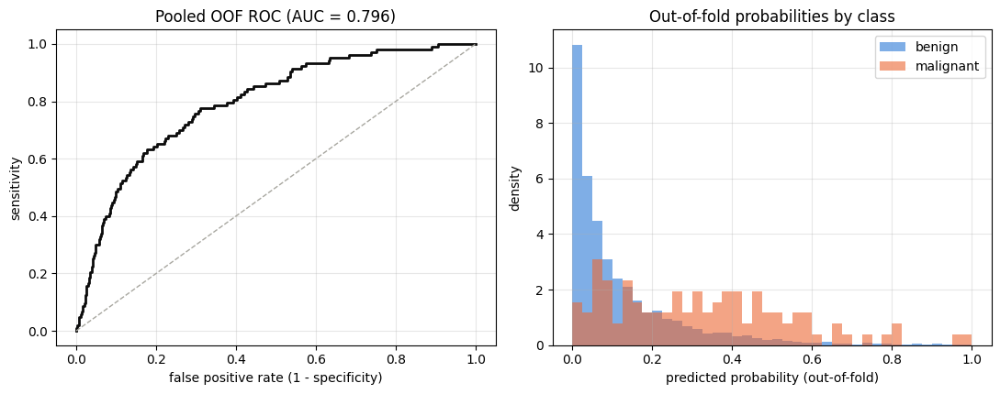

: 

: 

In [50]:
BENIGN_COLOR, MALIGNANT_COLOR = '#2a78d6', '#eb6834'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

axes[0].plot(fpr, tpr, color='#0b0b0b', linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='#a8a7a0', linewidth=1)
axes[0].set_xlabel('false positive rate (1 - specificity)')
axes[0].set_ylabel('sensitivity')
axes[0].set_title(f'Pooled OOF ROC (AUC = {roc_auc_score(y_oof, p_oof):.3f})')
axes[0].grid(alpha=0.3)

bins = np.linspace(0, 1, 41)
axes[1].hist(p_oof[y_oof == 0], bins=bins, color=BENIGN_COLOR, alpha=0.6, label='benign', density=True)
axes[1].hist(p_oof[y_oof == 1], bins=bins, color=MALIGNANT_COLOR, alpha=0.6, label='malignant', density=True)
axes[1].set_xlabel('predicted probability (out-of-fold)')
axes[1].set_ylabel('density')
axes[1].set_title('Out-of-fold probabilities by class')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Final model: retrain on the whole training set

Trained on every `training_set.csv` image with the same settings, for a **fixed number of epochs** (the median
best epoch across the 5 folds). The validation set stays unseen, so there's nothing left to early-stop on,
and the folds already showed how long training should run.

Its decision threshold is picked afterwards, on its own validation-set predictions, so the threshold and the
model share the same probability scale.

Saves `final_resnet_mlp.weights.h5` (head + frozen backbone) and `final_resnet_config.json` (settings +
threshold), also to Drive on Colab.

**Reruns don't retrain.** If a saved final model exists (locally or in Drive) and its settings match the ones
above, it's loaded instead of trained. Change any setting, or set `RETRAIN_FINAL = True`, to retrain. The 5-fold
CV works the same way: folds already in its result CSVs are skipped.

In [51]:
import json

FINAL_WEIGHTS = 'final_resnet_mlp.weights.h5'
FINAL_CONFIG = 'final_resnet_config.json'
RETRAIN_FINAL = False   # True = retrain even if a saved final model with the same settings exists

fold_summary = load_csv(FOLD_CSV)
median_best_epoch = int(round(fold_summary['best_epoch'].median()))
FINAL_EPOCHS = 10       # set by hand -- use median_best_epoch instead to follow the CV
print(f"best epochs per fold: {sorted(fold_summary['best_epoch'].tolist())} (median {median_best_epoch}) "
      f"-> final model uses {FINAL_EPOCHS} epochs")

# Everything that defines the final model -- a saved model is only reused if all of these match
FINAL_SETTINGS = {
    'image_source': CROPPED_DIR,
    'trained_on': f'training_set.csv ({len(y)} images)',
    'img_size': IMG_SIZE,
    'mlp_hidden_units': MLP_HIDDEN_UNITS,
    'input_dropout': INPUT_DROPOUT_RATE,
    'hidden_dropout': MLP_DROPOUT_RATES,
    'l2_strength': L2_STRENGTH,
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'target_minority_ratio': TARGET_MINORITY_RATIO,
    'class_weight_blend': CLASS_WEIGHT_BLEND,
    'final_epochs': FINAL_EPOCHS,
}

# Bring a saved copy over from Drive if this is a fresh runtime
for name in (FINAL_WEIGHTS, FINAL_CONFIG):
    if not os.path.exists(name) and os.path.exists(os.path.join(DRIVE_DIR, name)):
        shutil.copy(os.path.join(DRIVE_DIR, name), name)

saved_config = None
if os.path.exists(FINAL_WEIGHTS) and os.path.exists(FINAL_CONFIG):
    with open(FINAL_CONFIG) as fh:
        saved_config = json.load(fh)
mismatched = ([k for k, v in FINAL_SETTINGS.items() if saved_config.get(k) != v]
              if saved_config is not None else None)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
final_model = build_resnet_mlp()

if saved_config is not None and not mismatched and not RETRAIN_FINAL:
    final_model.load_weights(FINAL_WEIGHTS)
    final_model_trained_now = False
    print(f'loaded the saved final model from {FINAL_WEIGHTS} -- no retraining needed')
else:
    if mismatched:
        print(f'saved final model has different settings ({mismatched}) -- retraining')
    elif saved_config is None:
        print('no saved final model found -- training it now')
    final_history = final_model.fit(
        make_training_dataset(X, y, seed=SEED),
        epochs=FINAL_EPOCHS,
        class_weight=blended_class_weight(y),
        verbose=2,
    )
    final_model_trained_now = True
    plot_training_history(final_history, f'Final model: whole training set ({len(y)} images), {FINAL_EPOCHS} epochs')

best epochs per fold: [2, 3, 3, 4, 9] (median 3) -> final model uses 10 epochs
loaded the saved final model from final_resnet_mlp.weights.h5 -- no retraining needed


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


: 

: 

In [52]:
# Save the final model's weights -- skipped when it was just loaded from disk. Its config (settings +
# threshold) is saved further down, once the threshold has been picked on the validation set.
if final_model_trained_now:
    final_model.save_weights(FINAL_WEIGHTS)
    if os.path.isdir(DRIVE_DIR):
        shutil.copy(FINAL_WEIGHTS, os.path.join(DRIVE_DIR, FINAL_WEIGHTS))
    print(f'saved {FINAL_WEIGHTS}' + (' (also to Drive)' if os.path.isdir(DRIVE_DIR) else ''))
else:
    print(f'{FINAL_WEIGHTS} already saved -- nothing to do')

final_resnet_mlp.weights.h5 already saved -- nothing to do


: 

: 

## Prediction CSVs (`image_name`, `probability`)

- **Validation set:** the final model's probabilities on `validation_set.csv`, which it has never seen.
  This is the fusion model's training input.
- **Training set:** the **out-of-fold** probabilities from the 5-fold CV, so each training image is scored by
  a model that didn't train on it. Use these, not the final model's scores on its own training images
  (which are overconfident), if any training-set scores are ever needed.

Saved to `outputs/` and copied to `melanoma_outputs/` in Drive on Colab.

In [53]:
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

val_prob = final_model.predict(make_resnet_dataset(X_val), verbose=0).ravel()
prediction_files = {
    'resnet_mlp_validation_predictions.csv':
        pd.DataFrame({'image_name': val_df['image_name'], 'probability': val_prob}),
    'resnet_mlp_train_oof_predictions.csv':
        load_csv(OOF_CSV)[['image_name', 'probability']],
}
for name, df in prediction_files.items():
    df.to_csv(os.path.join(OUTPUT_DIR, name), index=False)
    print(f'saved {len(df)} rows -> {OUTPUT_DIR}/{name}')

if os.path.isdir(DRIVE_DIR):
    drive_output_dir = os.path.join(DRIVE_DIR, 'melanoma_outputs')
    os.makedirs(drive_output_dir, exist_ok=True)
    for name in prediction_files:
        shutil.copy(os.path.join(OUTPUT_DIR, name), os.path.join(drive_output_dir, name))
    print(f'copied to {drive_output_dir}/')

prediction_files['resnet_mlp_validation_predictions.csv'].head()

saved 1235 rows -> outputs/resnet_mlp_validation_predictions.csv
saved 5629 rows -> outputs/resnet_mlp_train_oof_predictions.csv
copied to /content/drive/MyDrive/melanoma_outputs/


,image_name,probability
0,ISIC_0082348,0.009063
1,ISIC_0109869,0.006542
2,ISIC_0179191,0.012864
3,ISIC_0192419,0.009407
4,ISIC_0196399,0.389542


: 

: 

## Threshold from the validation set

The final model predicts `validation_set.csv` (patients it never trained on), and `FINAL_THRESHOLD` is the
**highest threshold that still gives sensitivity >= `MIN_SENSITIVITY` (0.85)** on those predictions. It's picked on
the model that actually makes the final predictions, so the probability scale matches.

- **Fusion model unaffected:** it uses the validation *probabilities*, which don't depend on the threshold.
- **Noisier:** only ~25 validation melanomas, so each one is ~4 percentage points of sensitivity.
- **Validation performance is no longer an unbiased estimate:** the threshold was tuned there, so validation
  sensitivity is >= 0.85 by construction. The test set is the honest check.

Saves `final_resnet_config.json` (settings + `FINAL_THRESHOLD`), also to Drive -- the test section reads the
threshold from it.

FINAL_THRESHOLD  = 0.1315 (highest threshold with validation sensitivity >= 0.85)
validation ROC-AUC = 0.8501, PR-AUC = 0.1821; training OOF ROC-AUC = 0.7962
saved final_resnet_config.json (also to Drive)

validation: sensitivity = 0.880 (22/25 melanomas caught), specificity = 0.676, false alarms = 392 of 1210 benign

              precision    recall  f1-score   support

      benign      0.996     0.676     0.806      1210
   malignant      0.053     0.880     0.100        25

    accuracy                          0.680      1235
   macro avg      0.525     0.778     0.453      1235
weighted avg      0.977     0.680     0.791      1235



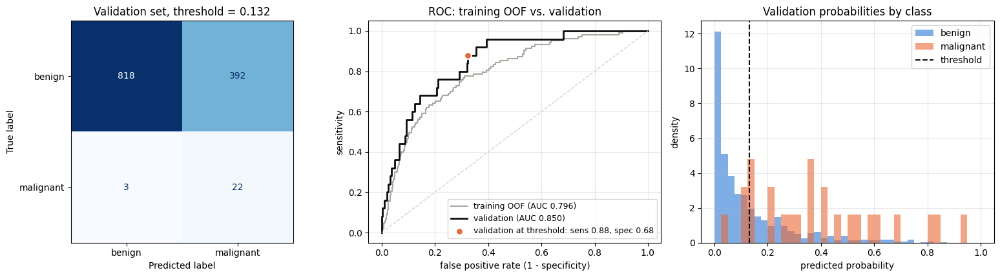

: 

: 

In [54]:
val_df_scored = val_df[['image_name', 'target']].assign(probability=val_prob)
y_v = val_df_scored['target'].to_numpy().astype(int)
p_v = val_df_scored['probability'].to_numpy()

# Same rule as the pooled threshold, on the final model's validation predictions
fpr_v, tpr_v, thresholds_v = roc_curve(y_v, p_v)
FINAL_THRESHOLD = float(thresholds_v[int(np.argmax(tpr_v >= MIN_SENSITIVITY))])
pred_v = (p_v >= FINAL_THRESHOLD).astype(int)
m_v = metrics_at(y_v, p_v, FINAL_THRESHOLD)

print(f'FINAL_THRESHOLD  = {FINAL_THRESHOLD:.4f} (highest threshold with validation sensitivity >= {MIN_SENSITIVITY})')

print(f'validation ROC-AUC = {roc_auc_score(y_v, p_v):.4f}, PR-AUC = {average_precision_score(y_v, p_v):.4f}; '
      f'training OOF ROC-AUC = {roc_auc_score(y_oof, p_oof):.4f}')

# Save the config the test section reads (settings + the validation-picked threshold)
final_config = {
    'model': 'ResNet50 (frozen, imagenet) + MLP head',
    'crop_margin': CROP_MARGIN,
    **FINAL_SETTINGS,
    'threshold': FINAL_THRESHOLD,
    'threshold_rule': f'highest threshold with validation-set sensitivity >= {MIN_SENSITIVITY} (final model)',
    'validation_roc_auc': float(roc_auc_score(y_v, p_v)),
    'validation_sensitivity': float(m_v['sensitivity']),
    'validation_specificity': float(m_v['specificity']),
    'pooled_oof_roc_auc': float(roc_auc_score(y_oof, p_oof)),
}
with open(FINAL_CONFIG, 'w') as fh:
    json.dump(final_config, fh, indent=2)
if os.path.isdir(DRIVE_DIR):
    shutil.copy(FINAL_CONFIG, os.path.join(DRIVE_DIR, FINAL_CONFIG))
print(f'saved {FINAL_CONFIG}' + (' (also to Drive)' if os.path.isdir(DRIVE_DIR) else ''))
print(f"\nvalidation: sensitivity = {m_v['sensitivity']:.3f} ({m_v['tp']}/{m_v['tp'] + m_v['fn']} melanomas caught), "
      f"specificity = {m_v['specificity']:.3f}, false alarms = {m_v['fp']} of {m_v['fp'] + m_v['tn']} benign\n")
print(classification_report(y_v, pred_v, target_names=['benign', 'malignant'], digits=3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ConfusionMatrixDisplay(confusion_matrix(y_v, pred_v, labels=[0, 1]),
                       display_labels=['benign', 'malignant']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Validation set, threshold = {FINAL_THRESHOLD:.3f}')

axes[1].plot(fpr, tpr, color='#a8a7a0', linewidth=1.5, label=f'training OOF (AUC {roc_auc_score(y_oof, p_oof):.3f})')
axes[1].plot(fpr_v, tpr_v, color='#0b0b0b', linewidth=2, label=f'validation (AUC {roc_auc_score(y_v, p_v):.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='#d4d3cd', linewidth=1)
axes[1].scatter([1 - m_v['specificity']], [m_v['sensitivity']], s=60, color=MALIGNANT_COLOR, edgecolor='white',
                linewidth=1.5, zorder=3, label=f"validation at threshold: sens {m_v['sensitivity']:.2f}, spec {m_v['specificity']:.2f}")
axes[1].set_xlabel('false positive rate (1 - specificity)')
axes[1].set_ylabel('sensitivity')
axes[1].set_title('ROC: training OOF vs. validation')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)

bins = np.linspace(0, 1, 41)
axes[2].hist(p_v[y_v == 0], bins=bins, color=BENIGN_COLOR, alpha=0.6, label='benign', density=True)
axes[2].hist(p_v[y_v == 1], bins=bins, color=MALIGNANT_COLOR, alpha=0.6, label='malignant', density=True)
axes[2].axvline(FINAL_THRESHOLD, color='#0b0b0b', linestyle='--', linewidth=1.5, label='threshold')
axes[2].set_xlabel('predicted probability')
axes[2].set_ylabel('density')
axes[2].set_title('Validation probabilities by class')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Test set (run once, when the test set arrives)

Test images must go through **exactly the same preprocessing** as the training crops:

1. DullRazor hair removal on the full-resolution image.
2. `crop_with_margin(image, 0.10)`: lesion box found by `boundary_localization_crop` (with the
   saturation fallback for light lesions), expanded by 10%, resized to 224×224.
3. Saved as JPEG and reloaded, like the training crops.

The crop code below is copied from `Crop_margin_ablation.ipynb`, the notebook that made the training crops.
It needs `boundary_localization.py` next to this notebook (on Colab, upload it to `/content`).

**In a fresh session** you don't need to retrain: run the setup cells (seed, Colab unpack, working
directory), the `load_images` definition, the augmentation cell and the model cell, then jump straight
here. The saved weights and threshold are reloaded from disk (or Drive).

**Getting the test images:** put `test.zip` in your Google Drive (`MyDrive/test.zip`) or next to this
notebook. The unzip cell extracts it to `test_raw/`, picks the folder with the images, and uses a labels
CSV from inside the zip if it has `image_name` and `target` columns. If the labels are somewhere else, set
`TEST_LABELS_CSV` by hand. Without labels, the section just saves predictions.

The zip should contain the **raw** test images (as downloaded, like `train/`), not already-cropped ones --
this section does the hair removal and cropping itself.

In [55]:
import shutil

# boundary_localization.py must sit next to this notebook (in /content on Colab) to be importable.
# On Colab, copy it in from Google Drive -- MyDrive/ itself, or anywhere else in Drive (searched if needed).
if os.path.isdir('/content') and not os.path.exists('boundary_localization.py'):
    if not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')
    candidates = ['/content/drive/MyDrive/boundary_localization.py']
    if not os.path.exists(candidates[0]):
        import glob
        candidates = glob.glob('/content/drive/MyDrive/**/boundary_localization.py', recursive=True)
    assert candidates and os.path.exists(candidates[0]), 'boundary_localization.py not found anywhere in MyDrive'
    shutil.copy(candidates[0], 'boundary_localization.py')
    print(f'copied {candidates[0]} -> {os.getcwd()}/boundary_localization.py')

import boundary_localization
from boundary_localization import (boundary_localization_crop, remove_marker, remove_dark_marker,
                                   strip_rectangular_artifacts)


def remove_hair(img_rgb, kernel_size=9, inpaint_radius=6, thresh=10):
    """DullRazor: blackhat filter finds dark thin hair-like structures, threshold them into a
    mask, and inpaint them from the surrounding skin."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blurred = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
    _, hair_mask = cv2.threshold(blurred, thresh, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img_rgb, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)


def remove_border_vignette(img_rgb, dark_thresh=60, inpaint_radius=6, morph_kernel_size=31, sat_thresh=50):
    """boundary_localization.remove_border_vignette plus a saturation check: a pixel only counts as
    vignette if it is dark AND nearly colourless, so a dark melanoma running off the edge isn't flat-filled."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    sat = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)[..., 1]
    dark_mask = ((gray < dark_thresh) & (sat < sat_thresh)).astype(np.uint8)

    if morph_kernel_size > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
        dark_mask = cv2.morphologyEx(dark_mask, cv2.MORPH_CLOSE, kernel)

    _, labels = cv2.connectedComponents(dark_mask)
    border_labels = set(labels[0, :]) | set(labels[-1, :]) | set(labels[:, 0]) | set(labels[:, -1])
    border_labels.discard(0)
    if not border_labels:
        return img_rgb, np.zeros_like(dark_mask, dtype=np.uint8)

    vignette_mask = np.isin(labels, list(border_labels)).astype(np.uint8) * 255
    non_vignette = vignette_mask == 0
    if not non_vignette.any():
        return cv2.inpaint(img_rgb, vignette_mask, inpaint_radius, cv2.INPAINT_TELEA), vignette_mask

    cleaned = img_rgb.copy()
    cleaned[vignette_mask == 255] = img_rgb[non_vignette].reshape(-1, 3).mean(axis=0)
    return cleaned, vignette_mask


# boundary_localization_crop looks remove_border_vignette up in its own module -- swap the patched
# version in there too, same as Crop_margin_ablation.ipynb did when making the training crops
boundary_localization.remove_border_vignette = remove_border_vignette


def clean_image(image):
    cleaned, _ = remove_marker(image)
    cleaned, _ = remove_dark_marker(cleaned)
    cleaned = strip_rectangular_artifacts(cleaned)
    cleaned, _ = remove_border_vignette(cleaned)
    return cleaned


GRAY_MIN_CONTRAST = 15
SAT_MIN_CONTRAST = 30
AGREE_IOU = 0.5
MARKER_HUES = (95, 155)


def _region_contrast(chan, mask, bbox_local):
    x, y_, w, h = bbox_local
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.boundingRect(c) == (x, y_, w, h)]
    if not contours:
        return 0.0
    inside = np.zeros(chan.shape, np.uint8)
    cv2.drawContours(inside, contours, -1, 255, cv2.FILLED)
    r = max(5, int(0.15 * max(w, h)))
    ring = cv2.dilate(inside, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1)))
    ring = (ring > 0) & (inside == 0)
    if not ring.any():
        return 0.0
    return float(chan[ring].mean() - chan[inside > 0].mean())


def _iou(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    iw = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    ih = max(0, min(ay + ah, by + bh) - max(ay, by))
    inter = iw * ih
    return inter / (aw * ah + bw * bh - inter)


def locate_lesion(image, cleaned):
    """(bbox, method): grayscale Otsu box if it clearly stands out (or agrees with the saturation box),
    else the saturation-based box for light lesions, else None (use the whole image)."""
    _, gray_bbox, gray_mask = boundary_localization_crop(image, output_size=None)
    gray = cv2.cvtColor(cleaned, cv2.COLOR_RGB2GRAY)
    contours, _ = cv2.findContours(gray_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    local = [cv2.boundingRect(c) for c in contours if cv2.boundingRect(c)[2:] == gray_bbox[2:]]
    gray_contrast = 0.0
    if local:
        ox, oy = gray_bbox[0] - local[0][0], gray_bbox[1] - local[0][1]
        mh, mw = gray_mask.shape
        gray_contrast = _region_contrast(gray[oy:oy + mh, ox:ox + mw].astype(np.float64), gray_mask, local[0])
    if gray_contrast >= GRAY_MIN_CONTRAST:
        return gray_bbox, 'gray'

    hsv = cv2.cvtColor(cleaned, cv2.COLOR_RGB2HSV)
    sat = hsv[..., 1].copy()
    sat[(hsv[..., 0] >= MARKER_HUES[0]) & (hsv[..., 0] <= MARKER_HUES[1])] = 0
    inv_sat = 255 - sat
    _, sat_bbox, sat_mask = boundary_localization_crop(
        np.repeat(inv_sat[..., None], 3, axis=2), output_size=None,
        strip_marker=False, strip_dark_marker=False, strip_rectangular=False,
        strip_border_vignette=False, strip_uniform_border=False)
    if _iou(gray_bbox, sat_bbox) >= AGREE_IOU:
        return gray_bbox, 'gray'
    if _region_contrast(inv_sat.astype(np.float64), sat_mask, sat_bbox) >= SAT_MIN_CONTRAST:
        return sat_bbox, 'saturation'
    return None, 'none'


def crop_with_margin(image, margin, output_size=IMG_SIZE):
    img_h, img_w = image.shape[:2]
    cleaned = clean_image(image)
    bbox, _ = locate_lesion(image, cleaned)
    if bbox is None:
        return cv2.resize(cleaned, (output_size, output_size), interpolation=cv2.INTER_AREA)
    x, y_, w, h = bbox
    mx, my = margin * w, margin * h
    x0 = max(0, int(round(x - mx)))
    y0 = max(0, int(round(y_ - my)))
    x1 = min(img_w, int(round(x + w + mx)))
    y1 = min(img_h, int(round(y_ + h + my)))
    return cv2.resize(cleaned[y0:y1, x0:x1], (output_size, output_size), interpolation=cv2.INTER_AREA)

: 

: 

In [56]:
# Unpack test.zip from Google Drive (or a local / directly-uploaded copy) into test_raw/, then find
# the folder that actually holds the images -- zips often nest them one level down -- and any labels CSV.
TEST_ZIP_NAME = 'test.zip'
TEST_RAW_DIR = 'test_raw'

if not os.path.isdir(TEST_RAW_DIR) or not os.listdir(TEST_RAW_DIR):
    if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')
    test_zip = next((z for z in (TEST_ZIP_NAME, os.path.join('/content/drive/MyDrive', TEST_ZIP_NAME))
                     if os.path.exists(z)), None)
    assert test_zip, f'{TEST_ZIP_NAME} not found locally or in /content/drive/MyDrive/'
    os.makedirs(TEST_RAW_DIR, exist_ok=True)
    with zipfile.ZipFile(test_zip) as zf:
        zf.extractall(TEST_RAW_DIR)
    print(f'unzipped {test_zip} -> {TEST_RAW_DIR}/')

image_exts = ('.jpg', '.jpeg', '.png')
image_dirs, csv_files = {}, []
for dirpath, _, filenames in os.walk(TEST_RAW_DIR):
    if '__MACOSX' in dirpath:
        continue
    n_images = sum(f.lower().endswith(image_exts) and not f.startswith('._') for f in filenames)
    if n_images:
        image_dirs[dirpath] = n_images
    csv_files += [os.path.join(dirpath, f) for f in filenames if f.lower().endswith('.csv') and not f.startswith('._')]

assert image_dirs, f'no images found in {TEST_RAW_DIR}/'
TEST_DIR = max(image_dirs, key=image_dirs.get)   # the folder with the most images
print(f'test images: {image_dirs[TEST_DIR]} in {TEST_DIR}/' +
      (f'  (other image folders: {dict((d, n) for d, n in image_dirs.items() if d != TEST_DIR)})' if len(image_dirs) > 1 else ''))

# A labels CSV inside the zip is used automatically if it has image_name + target columns
TEST_LABELS_CSV = None
for path in csv_files:
    cols = set(pd.read_csv(path, nrows=0).columns)
    print(f'found CSV: {path} with columns {sorted(cols)}')
    if {'image_name', 'target'} <= cols:
        TEST_LABELS_CSV = path
print(f'labels: {TEST_LABELS_CSV or "none found -- predictions only (set TEST_LABELS_CSV by hand if the labels are elsewhere)"}')

test images: 1988 in test_raw/test/
labels: none found -- predictions only (set TEST_LABELS_CSV by hand if the labels are elsewhere)


: 

: 

In [57]:
# TEST_DIR / TEST_LABELS_CSV come from the unzip cell above -- override here if needed
if TEST_LABELS_CSV is None:
    # test_labels.csv uploaded separately -- next to this notebook / in /content, or in Drive
    TEST_LABELS_CSV = next((c for c in ('test_labels.csv', '/content/drive/MyDrive/test_labels.csv')
                            if os.path.exists(c)), None)
print(f'labels: {TEST_LABELS_CSV or "none -- predictions only"}')
TEST_CROPPED_DIR = f'test_cropped_margin_{CROP_MARGIN:.2f}'

TEST_CROPPED_ZIP = f'melanoma_test_cropped_margin_{CROP_MARGIN:.2f}.zip'
DRIVE_TEST_CROPPED_ZIP = os.path.join('/content/drive/MyDrive', TEST_CROPPED_ZIP)

test_files = sorted(f for f in os.listdir(TEST_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._'))
os.makedirs(TEST_CROPPED_DIR, exist_ok=True)

# Restore previously-made crops (local zip, then Drive) instead of re-cropping every image
if not os.listdir(TEST_CROPPED_DIR):
    cached_zip = next((z for z in (TEST_CROPPED_ZIP, DRIVE_TEST_CROPPED_ZIP) if os.path.exists(z)), None)
    if cached_zip:
        with zipfile.ZipFile(cached_zip) as zf:
            zf.extractall(TEST_CROPPED_DIR)
        print(f'restored {len(os.listdir(TEST_CROPPED_DIR))} test crops from {cached_zip}')
already = set(os.listdir(TEST_CROPPED_DIR))
todo = [f for f in test_files if f not in already]
print(f'{len(test_files)} test images, {len(todo)} to preprocess (hair removal + {CROP_MARGIN:.0%}-margin crop)')

for i, fname in enumerate(todo):
    with Image.open(os.path.join(TEST_DIR, fname)) as img:
        raw = np.array(img.convert('RGB'))
    crop = crop_with_margin(remove_hair(raw), CROP_MARGIN)
    Image.fromarray(crop).save(os.path.join(TEST_CROPPED_DIR, fname))  # same JPEG save as the training crops
    if (i + 1) % 200 == 0:
        print(f'{i + 1}/{len(todo)} done')

# Zip the crops and copy them to Drive whenever new ones were made (or Drive has no copy yet)
if os.path.isdir('/content/drive/MyDrive') and (todo or not os.path.exists(DRIVE_TEST_CROPPED_ZIP)):
    with zipfile.ZipFile(TEST_CROPPED_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fname in sorted(os.listdir(TEST_CROPPED_DIR)):
            zf.write(os.path.join(TEST_CROPPED_DIR, fname), arcname=fname)
    shutil.copy(TEST_CROPPED_ZIP, DRIVE_TEST_CROPPED_ZIP)
    print(f'saved {len(os.listdir(TEST_CROPPED_DIR))} test crops to {DRIVE_TEST_CROPPED_ZIP}')

X_test = load_images(test_files, TEST_CROPPED_DIR)
test_names = [os.path.splitext(f)[0] for f in test_files]
print(X_test.shape)

labels: /content/drive/MyDrive/test_labels.csv
1988 test images, 0 to preprocess (hair removal + 10%-margin crop)
(1988, 224, 224, 3)


: 

: 

threshold = 0.1315 (highest threshold with validation-set sensitivity >= 0.85 (final model))
saved outputs/resnet_mlp_test_predictions.csv -- 503 of 1988 above the threshold (0.1315)

/content/drive/MyDrive/test_labels.csv: 1988 rows, columns ['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']

test: 1988 images, 31 malignant
test ROC-AUC = 0.8440, PR-AUC = 0.1330
at threshold 0.1315: sensitivity = 0.774 (24/31 melanomas caught), specificity = 0.755, precision = 0.048, false alarms = 479 of 1957 benign

              precision    recall  f1-score   support

      benign      0.995     0.755     0.859      1957
   malignant      0.048     0.774     0.090        31

    accuracy                          0.756      1988
   macro avg      0.521     0.765     0.474      1988
weighted avg      0.981     0.756     0.847      1988



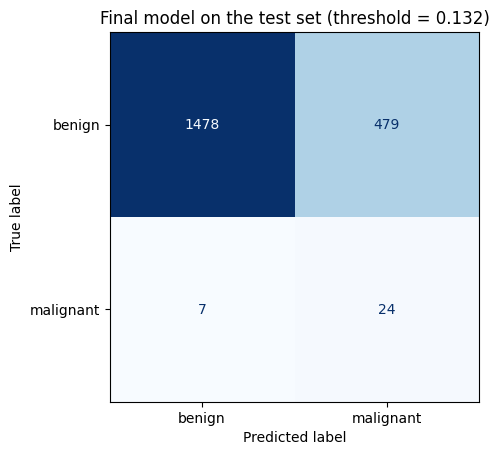

: 

: 

In [58]:
import json
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)


def metrics_at(y_true, prob, threshold):
    tn, fp, fn, tp = confusion_matrix(y_true, (prob >= threshold).astype(int), labels=[0, 1]).ravel()
    return {'sensitivity': tp / (tp + fn), 'specificity': tn / (tn + fp),
            'precision': tp / (tp + fp) if tp + fp else 0.0, 'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn}


FINAL_WEIGHTS = 'final_resnet_mlp.weights.h5'
FINAL_CONFIG = 'final_resnet_config.json'
DRIVE_DIR = '/content/drive/MyDrive'

# Reload the saved final model + threshold if this is a fresh session
for name in (FINAL_WEIGHTS, FINAL_CONFIG):
    if not os.path.exists(name) and os.path.exists(os.path.join(DRIVE_DIR, name)):
        shutil.copy(os.path.join(DRIVE_DIR, name), name)
if 'final_model' not in globals():
    final_model = build_resnet_mlp()
    final_model.load_weights(FINAL_WEIGHTS)
with open(FINAL_CONFIG) as fh:
    final_config = json.load(fh)
FINAL_THRESHOLD = final_config['threshold']
print(f"threshold = {FINAL_THRESHOLD:.4f} ({final_config['threshold_rule']})")

test_prob = final_model.predict(make_resnet_dataset(X_test), verbose=0).ravel()
test_pred = (test_prob >= FINAL_THRESHOLD).astype(int)

os.makedirs('outputs', exist_ok=True)
test_predictions = pd.DataFrame({'image_name': test_names, 'probability': test_prob})
test_predictions.to_csv('outputs/resnet_mlp_test_predictions.csv', index=False)
if os.path.isdir(DRIVE_DIR):
    os.makedirs(os.path.join(DRIVE_DIR, 'melanoma_outputs'), exist_ok=True)
    shutil.copy('outputs/resnet_mlp_test_predictions.csv',
                os.path.join(DRIVE_DIR, 'melanoma_outputs', 'resnet_mlp_test_predictions.csv'))
print(f'saved outputs/resnet_mlp_test_predictions.csv -- {test_pred.sum()} of {len(test_pred)} '
      f'above the threshold ({FINAL_THRESHOLD:.4f})')

if TEST_LABELS_CSV:
    test_labels = pd.read_csv(TEST_LABELS_CSV)
    print(f'\n{TEST_LABELS_CSV}: {len(test_labels)} rows, columns {list(test_labels.columns)}')
    if 'target' not in test_labels.columns and 'benign_malignant' in test_labels.columns:
        test_labels['target'] = (test_labels['benign_malignant'].str.lower() == 'malignant').astype(int)
    assert {'image_name', 'target'} <= set(test_labels.columns), \
        'labels CSV needs image_name and target (or benign_malignant) columns'
    labelled = test_predictions.merge(test_labels[['image_name', 'target']], on='image_name')
    assert len(labelled) == len(test_predictions), \
        f'{len(test_predictions) - len(labelled)} test images have no label (check image_name values match the filenames)'

    y_t, p_t = labelled['target'].to_numpy().astype(int), labelled['probability'].to_numpy()
    pred_t = (p_t >= FINAL_THRESHOLD).astype(int)
    m = metrics_at(y_t, p_t, FINAL_THRESHOLD)
    print(f'\ntest: {len(y_t)} images, {y_t.sum()} malignant')
    print(f'test ROC-AUC = {roc_auc_score(y_t, p_t):.4f}, PR-AUC = {average_precision_score(y_t, p_t):.4f}')
    print(f"at threshold {FINAL_THRESHOLD:.4f}: sensitivity = {m['sensitivity']:.3f} ({m['tp']}/{m['tp'] + m['fn']} melanomas caught), "
          f"specificity = {m['specificity']:.3f}, precision = {m['precision']:.3f}, "
          f"false alarms = {m['fp']} of {m['fp'] + m['tn']} benign\n")
    print(classification_report(y_t, pred_t, target_names=['benign', 'malignant'], digits=3))

    ConfusionMatrixDisplay(confusion_matrix(y_t, pred_t, labels=[0, 1]),
                           display_labels=['benign', 'malignant']).plot(cmap='Blues', colorbar=False)
    plt.title(f'Final model on the test set (threshold = {FINAL_THRESHOLD:.3f})')
    plt.show()

### ROC curves: training OOF vs. validation vs. test

One curve per set (whichever are available), each with a dot where the saved threshold puts it. The
thin grey horizontal line is the 0.85 sensitivity target. Saved to `outputs/resnet_mlp_roc.png` (and Drive).

Training (5-fold OOF)  AUC = 0.796 | at threshold: sensitivity = 0.777, specificity = 0.685
Validation             AUC = 0.850 | at threshold: sensitivity = 0.880, specificity = 0.676
Test                   AUC = 0.844 | at threshold: sensitivity = 0.774, specificity = 0.755


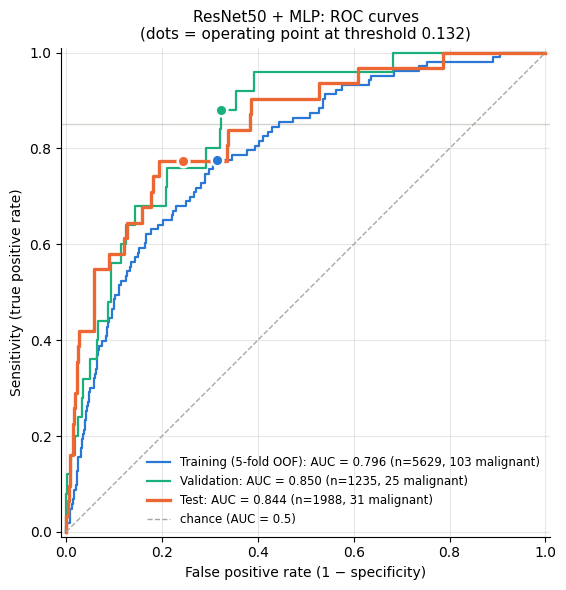

saved outputs/resnet_mlp_roc.png


: 

: 

In [59]:
from sklearn.metrics import roc_curve

# ROC curves for every set we have labels + probabilities for, each with the operating point at the saved threshold.
# Reads saved CSVs where possible, so it also works in a fresh session after only the test cells have run.
roc_sets = []

oof_path = next((c for c in ('final_resnet_trainset_oof_cv.csv', '/content/drive/MyDrive/final_resnet_trainset_oof_cv.csv')
                 if os.path.exists(c)), None)
if oof_path:
    oof = pd.read_csv(oof_path)
    roc_sets.append(('Training (5-fold OOF)', oof['target'].to_numpy().astype(int), oof['probability'].to_numpy(), '#2a78d6'))

val_path = next((c for c in ('outputs/resnet_mlp_validation_predictions.csv',
                             '/content/drive/MyDrive/melanoma_outputs/resnet_mlp_validation_predictions.csv')
                 if os.path.exists(c)), None)
if val_path and 'val_df' in globals():
    val_scored = pd.read_csv(val_path).merge(val_df[['image_name', 'target']], on='image_name')
    roc_sets.append(('Validation', val_scored['target'].to_numpy().astype(int), val_scored['probability'].to_numpy(), '#1baf7a'))

assert TEST_LABELS_CSV, 'no test labels -- run the cells above with test_labels.csv available'
roc_sets.append(('Test', y_t, p_t, '#eb6834'))

fig, ax = plt.subplots(figsize=(6.4, 6))
for name, y_true, prob, color in roc_sets:
    fpr_c, tpr_c, _ = roc_curve(y_true, prob)
    auc = roc_auc_score(y_true, prob)
    m_c = metrics_at(y_true, prob, FINAL_THRESHOLD)
    ax.plot(fpr_c, tpr_c, color=color, linewidth=2.4 if name == 'Test' else 1.6,
            label=f'{name}: AUC = {auc:.3f} (n={len(y_true)}, {int(y_true.sum())} malignant)')
    ax.scatter([1 - m_c['specificity']], [m_c['sensitivity']], s=70, color=color, edgecolor='white',
               linewidth=1.8, zorder=3)
    print(f"{name:22s} AUC = {auc:.3f} | at threshold: sensitivity = {m_c['sensitivity']:.3f}, "
          f"specificity = {m_c['specificity']:.3f}")

ax.plot([0, 1], [0, 1], linestyle='--', color='#a8a7a0', linewidth=1, label='chance (AUC = 0.5)')
ax.axhline(MIN_SENSITIVITY if 'MIN_SENSITIVITY' in globals() else 0.85, color='#d4d3cd', linewidth=1, zorder=0)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_aspect('equal')
ax.set_xlabel('False positive rate (1 − specificity)')
ax.set_ylabel('Sensitivity (true positive rate)')
ax.set_title(f'ResNet50 + MLP: ROC curves\n(dots = operating point at threshold {FINAL_THRESHOLD:.3f})', fontsize=11)
ax.legend(loc='lower right', fontsize=8.5, frameon=False)
ax.grid(alpha=0.3)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

os.makedirs('outputs', exist_ok=True)
fig.savefig('outputs/resnet_mlp_roc.png', dpi=200, bbox_inches='tight', facecolor='white')
if os.path.isdir('/content/drive/MyDrive'):
    os.makedirs('/content/drive/MyDrive/melanoma_outputs', exist_ok=True)
    shutil.copy('outputs/resnet_mlp_roc.png', '/content/drive/MyDrive/melanoma_outputs/resnet_mlp_roc.png')
plt.show()
print('saved outputs/resnet_mlp_roc.png')

### Test-set melanomas: image, ID and predicted probability

Every malignant test image as the model saw it (hair removed, 10%-margin crop), sorted from highest to lowest
probability. Each is marked **caught** (probability >= `FINAL_THRESHOLD`) or **missed**, with a red border on the
missed ones. Saved to `outputs/resnet_mlp_test_melanomas.png`.

31 test melanomas: 24 caught, 7 missed at threshold 0.1315


,image_name,probability,caught
0,ISIC_9998682,0.9127,True
1,ISIC_2033237,0.8293,True
2,ISIC_1959939,0.7911,True
3,ISIC_2311665,0.7665,True
4,ISIC_8231999,0.7647,True
5,ISIC_3244067,0.6393,True
6,ISIC_4523238,0.6315,True
7,ISIC_9593940,0.5751,True
8,ISIC_4851366,0.5549,True
9,ISIC_2320481,0.5168,True


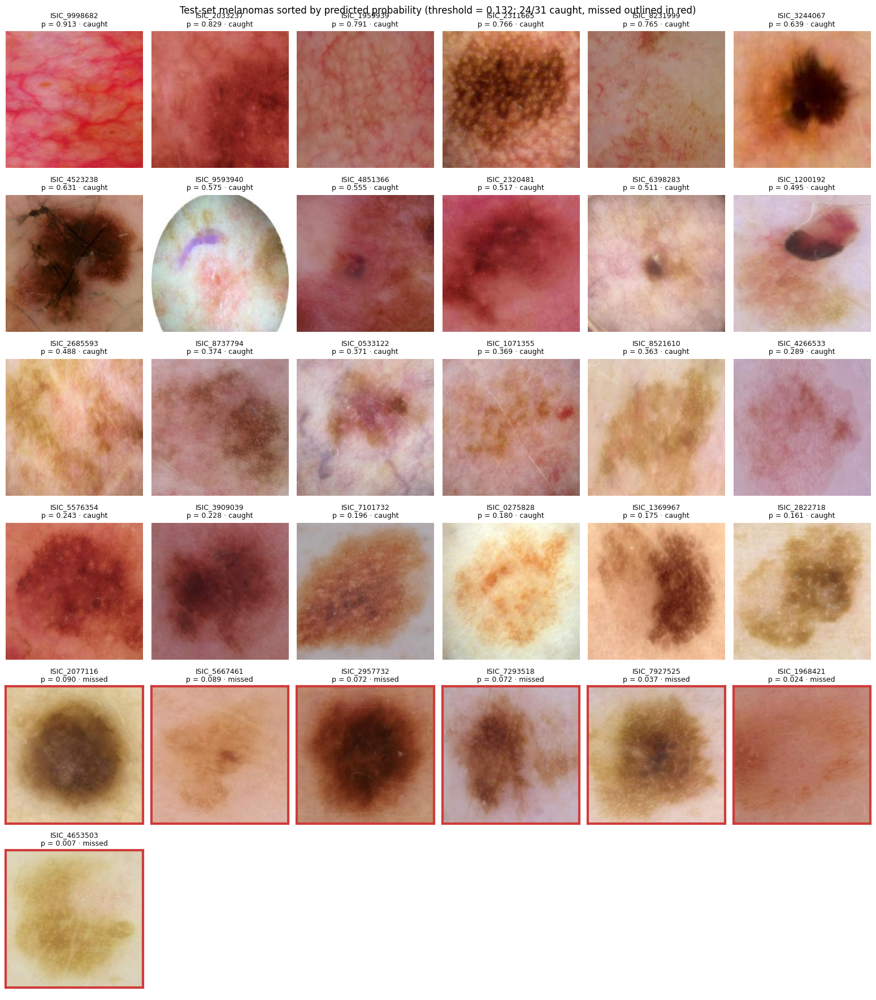

: 

: 

In [60]:
MISSED_COLOR = '#d03b3b'
N_COLS = 6

name_to_idx = {n: i for i, n in enumerate(test_names)}
mel = labelled[labelled['target'] == 1].sort_values('probability', ascending=False).reset_index(drop=True)
n_caught = int((mel['probability'] >= FINAL_THRESHOLD).sum())
print(f'{len(mel)} test melanomas: {n_caught} caught, {len(mel) - n_caught} missed at threshold {FINAL_THRESHOLD:.4f}')
display(mel[['image_name', 'probability']].assign(
    caught=mel['probability'] >= FINAL_THRESHOLD).round({'probability': 4}))

n_rows = int(np.ceil(len(mel) / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(2.6 * N_COLS, 3.0 * n_rows), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')
for ax, (_, row) in zip(axes.ravel(), mel.iterrows()):
    caught = row['probability'] >= FINAL_THRESHOLD
    ax.imshow(X_test[name_to_idx[row['image_name']]])
    ax.set_title(f"{row['image_name']}\np = {row['probability']:.3f} · {'caught' if caught else 'missed'}",
                 fontsize=9, color='#0b0b0b')
    if not caught:   # red frame around missed melanomas
        ax.axis('on')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(MISSED_COLOR)
            spine.set_linewidth(3)
fig.suptitle(f'Test-set melanomas sorted by predicted probability (threshold = {FINAL_THRESHOLD:.3f}; '
             f'{n_caught}/{len(mel)} caught, missed outlined in red)', fontsize=12)
plt.tight_layout()

os.makedirs('outputs', exist_ok=True)
fig.savefig('outputs/resnet_mlp_test_melanomas.png', dpi=150, bbox_inches='tight', facecolor='white')
if os.path.isdir('/content/drive/MyDrive'):
    os.makedirs('/content/drive/MyDrive/melanoma_outputs', exist_ok=True)
    shutil.copy('outputs/resnet_mlp_test_melanomas.png', '/content/drive/MyDrive/melanoma_outputs/resnet_mlp_test_melanomas.png')
plt.show()

### Grad-CAM: where does the model look on the test melanomas?

Grad-CAM takes the gradient of the malignant probability with respect to ResNet50's last convolutional
feature map (`conv5_block3_out`, 7×7×2048), weights each of the 2048 channels by its average gradient, and
sums them into a 7×7 heatmap, upsampled onto the image. **Red = regions that pushed the prediction towards
malignant.**

Things to look for:
- **Caught melanomas:** is the heat on the lesion itself, or on skin, corners or artifacts (ruler marks,
  vignette, leftover hair)?
- **Missed melanomas** (red border): is the model looking at the wrong place, or at the right place but not
  convinced?

The heatmap is normalised per image, so it shows *where* the model looked, not *how strongly* -- compare
probabilities for that. Same order as the grid above (highest probability first). Saved to
`outputs/resnet_mlp_test_melanomas_gradcam.png`.

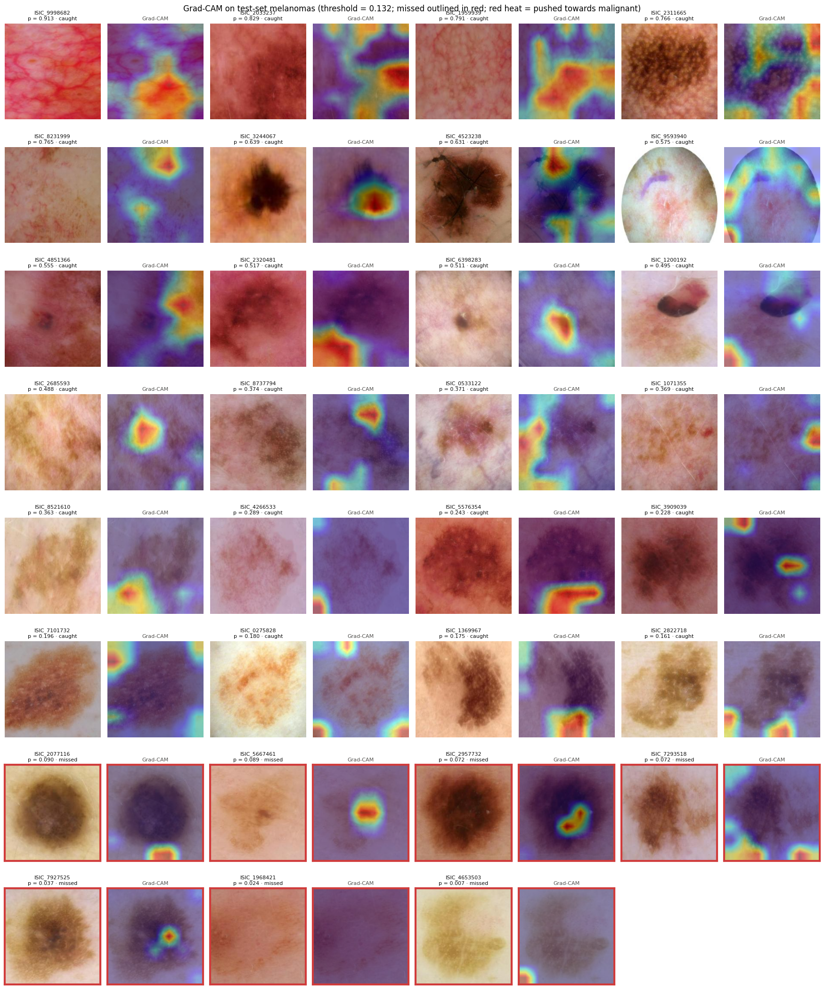

: 

: 

In [61]:
GRADCAM_LAYER = 'conv5_block3_out'   # last conv block of ResNet50 (7x7x2048), before global average pooling
GRADCAM_ALPHA = 0.4                   # heatmap opacity on the overlay
PAIRS_PER_ROW = 4                     # each melanoma = image + overlay, so 8 columns

# The ResNet50 backbone is nested inside final_model as a single layer -- build a model from the backbone's
# own input to [last conv feature map, pooled features], then replay the MLP head on the pooled features
backbone = next(l for l in final_model.layers if isinstance(l, tf.keras.Model))
head_layers = final_model.layers[final_model.layers.index(backbone) + 1:]
conv_and_pooled = tf.keras.Model(backbone.input, [backbone.get_layer(GRADCAM_LAYER).output, backbone.output])


def gradcam(img_uint8):
    batch = resnet_preprocess_input(img_uint8.astype(np.float32)[None])
    with tf.GradientTape() as tape:
        conv_out, pooled = conv_and_pooled(batch, training=False)
        tape.watch(conv_out)
        x = pooled
        for layer in head_layers:
            x = layer(x, training=False)
        score = x[:, 0]                      # malignant probability
    grads = tape.gradient(score, conv_out)[0]                # (7, 7, 2048)
    weights = tf.reduce_mean(grads, axis=(0, 1))             # one weight per channel
    cam = tf.nn.relu(tf.reduce_sum(conv_out[0] * weights, axis=-1)).numpy()
    cam = cam / (cam.max() + 1e-8)
    return cam, float(x[0, 0])


def overlay(img_uint8, cam, alpha=GRADCAM_ALPHA):
    cam_big = cv2.resize(cam, (img_uint8.shape[1], img_uint8.shape[0]))
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam_big), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return (heat * alpha + img_uint8 * (1 - alpha)).astype(np.uint8)


# Sanity check: the replayed head must reproduce the model's own prediction
first = X_test[name_to_idx[mel.loc[0, 'image_name']]]
_, replay_p = gradcam(first)
assert abs(replay_p - mel.loc[0, 'probability']) < 1e-3, (replay_p, mel.loc[0, 'probability'])

n_rows = int(np.ceil(len(mel) / PAIRS_PER_ROW))
fig, axes = plt.subplots(n_rows, 2 * PAIRS_PER_ROW, figsize=(2.2 * 2 * PAIRS_PER_ROW, 2.7 * n_rows), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')
for k, row in mel.iterrows():
    img = X_test[name_to_idx[row['image_name']]]
    cam, _ = gradcam(img)
    caught = row['probability'] >= FINAL_THRESHOLD
    ax_img, ax_cam = axes[k // PAIRS_PER_ROW, 2 * (k % PAIRS_PER_ROW)], axes[k // PAIRS_PER_ROW, 2 * (k % PAIRS_PER_ROW) + 1]
    ax_img.imshow(img)
    ax_cam.imshow(overlay(img, cam))
    ax_img.set_title(f"{row['image_name']}\np = {row['probability']:.3f} · {'caught' if caught else 'missed'}",
                     fontsize=8, color='#0b0b0b')
    ax_cam.set_title('Grad-CAM', fontsize=8, color='#52514e')
    if not caught:   # red frame around missed melanomas, same as the grid above
        for ax in (ax_img, ax_cam):
            ax.axis('on')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(MISSED_COLOR)
                spine.set_linewidth(3)
fig.suptitle(f'Grad-CAM on test-set melanomas (threshold = {FINAL_THRESHOLD:.3f}; missed outlined in red; '
             f'red heat = pushed towards malignant)', fontsize=12)
plt.tight_layout()

fig.savefig('outputs/resnet_mlp_test_melanomas_gradcam.png', dpi=150, bbox_inches='tight', facecolor='white')
if os.path.isdir('/content/drive/MyDrive'):
    shutil.copy('outputs/resnet_mlp_test_melanomas_gradcam.png',
                '/content/drive/MyDrive/melanoma_outputs/resnet_mlp_test_melanomas_gradcam.png')
plt.show()

### Test-set score distribution with the threshold

Predicted probability for every test image, benign vs. melanoma, with the decision threshold drawn on top.
Everything to the **right** of the threshold line gets flagged as malignant.

- **Left -- histograms as % of each class:** each bar is the share of that class falling in the bin, so the 31
  melanomas are as visible as the ~1,950 benign images. Shows how much the two distributions overlap.
- **Right -- every image as a dot** (benign faint, melanomas solid, randomly spread vertically so they don't
  overlap): melanomas left of the line are missed, benign dots right of it are false alarms.

The x-axis is log-scaled by default (`LOG_X`) because most scores sit close to 0. Saved to
`outputs/resnet_mlp_test_score_distribution.png`.

final, sens. >= 0.85 on validation (0.132)    melanomas caught 24/31 (77%), false alarms 479/1957 (24%)
median score -- benign 0.0427, melanoma 0.3693


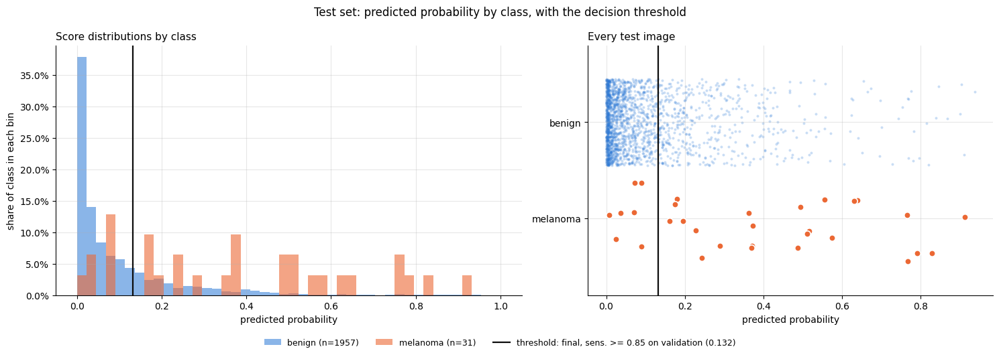

: 

: 

In [62]:
import matplotlib

LOG_X = False
BENIGN_COLOR, MALIGNANT_COLOR = '#2a78d6', '#eb6834'
THRESHOLD_STYLES = [('-', '#0b0b0b'), ('--', '#52514e'), (':', '#52514e')]

min_sens = MIN_SENSITIVITY if 'MIN_SENSITIVITY' in globals() else 0.85   # fresh session that only ran the test cells
thresholds_to_show = [(f'final, sens. >= {min_sens} on validation ({FINAL_THRESHOLD:.3f})', FINAL_THRESHOLD)]

benign_p, mel_p = p_t[y_t == 0], p_t[y_t == 1]
lo = max(min(p_t.min(), min(t for _, t in thresholds_to_show)) * 0.8, 1e-5)
bins = np.logspace(np.log10(lo), 0, 45) if LOG_X else np.linspace(0, 1, 45)

fig, (ax_h, ax_s) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.15, 1]})

# Each bar = share of that class in the bin (not density=True, which divides by bin width and would
# squash the wide right-hand bins of a log-scaled axis)
ax_h.hist(benign_p, bins=bins, weights=np.full(len(benign_p), 1 / len(benign_p)), color=BENIGN_COLOR,
          alpha=0.55, label=f'benign (n={len(benign_p)})')
ax_h.hist(mel_p, bins=bins, weights=np.full(len(mel_p), 1 / len(mel_p)), color=MALIGNANT_COLOR,
          alpha=0.6, label=f'melanoma (n={len(mel_p)})')
ax_h.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax_h.set_ylabel('share of class in each bin')
ax_h.set_title('Score distributions by class', loc='left', fontsize=11)

rng = np.random.default_rng(0)
ax_s.scatter(benign_p, rng.uniform(0.55, 1.45, len(benign_p)), s=8, color=BENIGN_COLOR, alpha=0.25,
             linewidth=0, label='benign')
ax_s.scatter(mel_p, rng.uniform(-0.45, 0.45, len(mel_p)), s=46, color=MALIGNANT_COLOR, edgecolor='white',
             linewidth=1.2, zorder=3, label='melanoma')
ax_s.set_yticks([0, 1], ['melanoma', 'benign'])
ax_s.set_ylim(-0.8, 1.8)
ax_s.set_title('Every test image', loc='left', fontsize=11)

for ax in (ax_h, ax_s):
    for (name, thr), (ls, color) in zip(thresholds_to_show, THRESHOLD_STYLES):
        ax.axvline(thr, color=color, linestyle=ls, linewidth=1.6, label=f'threshold: {name}')
    if LOG_X:
        ax.set_xscale('log')
    ax.set_xlabel('predicted probability' + (' (log scale)' if LOG_X else ''))
    ax.grid(alpha=0.3)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
fig.legend(*ax_h.get_legend_handles_labels(), loc='lower center', ncol=4, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.06))

for name, thr in thresholds_to_show:
    caught, fa = int((mel_p >= thr).sum()), int((benign_p >= thr).sum())
    print(f'{name:45s} melanomas caught {caught}/{len(mel_p)} ({caught / len(mel_p):.0%}), '
          f'false alarms {fa}/{len(benign_p)} ({fa / len(benign_p):.0%})')
print(f'median score -- benign {np.median(benign_p):.4f}, melanoma {np.median(mel_p):.4f}')

fig.suptitle('Test set: predicted probability by class, with the decision threshold', fontsize=12)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
fig.savefig('outputs/resnet_mlp_test_score_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
if os.path.isdir('/content/drive/MyDrive'):
    os.makedirs('/content/drive/MyDrive/melanoma_outputs', exist_ok=True)
    shutil.copy('outputs/resnet_mlp_test_score_distribution.png',
                '/content/drive/MyDrive/melanoma_outputs/resnet_mlp_test_score_distribution.png')
plt.show()

## Original (unprocessed) test images on the same model

What happens if the **original** test images go into the final model instead of the hair-removed 10%-margin crops?
Same `final_model`, same `FINAL_THRESHOLD`. The only change is the input: the raw images from `TEST_DIR`,
resized straight to 224×224 with the same `load_images` (no hair removal, no marker/vignette cleaning, no lesion crop).

How to read it:
- The model was **trained on crops only**, so originals are a distribution shift. The lesion is smaller in the frame,
  with more skin, hair, ruler marks and vignette. This measures how much the model depends on the preprocessing,
  not how it would perform if deployed as designed.
- **ROC-AUC / PR-AUC** don't depend on the threshold, so they're the fairest comparison. The threshold was picked on
  *cropped* validation images, so its probability scale may not carry over: a change in sensitivity/specificity can
  come from a shifted scale rather than worse ranking. Check the scatter plot.

Needs the test section above to have run (`test_files`, `TEST_DIR`, `labelled`, `final_model`, `FINAL_THRESHOLD`).
Saves `outputs/resnet_mlp_test_original_predictions.csv`.

saved outputs/resnet_mlp_test_original_predictions.csv (1988 rows)
1988 test images, 31 malignant; threshold = 0.1315 (picked on cropped validation images)


,ROC-AUC,PR-AUC,sensitivity,specificity,precision,tp,fn,fp,tn,% flagged
test images,,,,,,,,,,
cropped + hair removed (as trained),0.8440,0.1330,0.7742,0.7552,0.0477,24,7,479,1478,25.3018
original images,0.7464,0.0377,0.9677,0.2524,0.0201,30,1,1463,494,75.1006


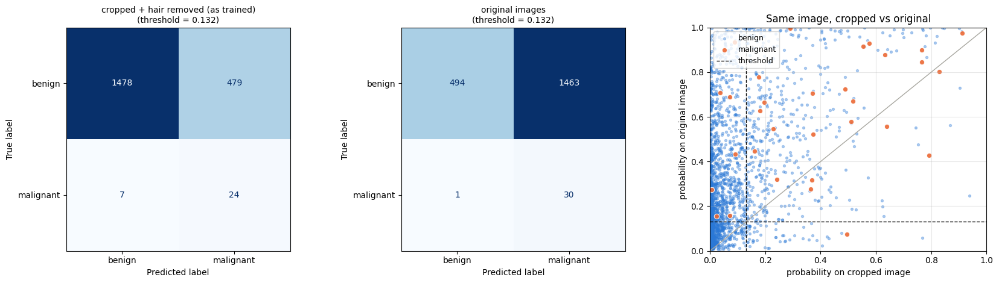

: 

: 

In [63]:
BENIGN_COLOR, MALIGNANT_COLOR = '#2a78d6', '#eb6834'

# Same model + threshold, original test images resized straight to 224x224
X_test_orig = load_images(test_files, TEST_DIR)
test_prob_orig = final_model.predict(make_resnet_dataset(X_test_orig), verbose=0).ravel()

orig_predictions = pd.DataFrame({'image_name': test_names, 'probability': test_prob_orig})
orig_predictions.to_csv('outputs/resnet_mlp_test_original_predictions.csv', index=False)
if os.path.isdir(DRIVE_DIR):
    shutil.copy('outputs/resnet_mlp_test_original_predictions.csv',
                os.path.join(DRIVE_DIR, 'melanoma_outputs', 'resnet_mlp_test_original_predictions.csv'))
print(f'saved outputs/resnet_mlp_test_original_predictions.csv ({len(orig_predictions)} rows)')

assert TEST_LABELS_CSV, 'needs the test labels (run the test section above with TEST_LABELS_CSV set)'
both = (labelled[['image_name', 'target', 'probability']].rename(columns={'probability': 'prob_crop'})
        .merge(orig_predictions.rename(columns={'probability': 'prob_original'}), on='image_name'))
y_b = both['target'].to_numpy().astype(int)

versions = [('cropped + hair removed (as trained)', 'prob_crop'), ('original images', 'prob_original')]
rows = []
for label, col in versions:
    p = both[col].to_numpy()
    rows.append({'test images': label, 'ROC-AUC': roc_auc_score(y_b, p), 'PR-AUC': average_precision_score(y_b, p),
                 **metrics_at(y_b, p, FINAL_THRESHOLD), '% flagged': 100 * (p >= FINAL_THRESHOLD).mean()})
print(f'{len(both)} test images, {y_b.sum()} malignant; threshold = {FINAL_THRESHOLD:.4f} (picked on cropped validation images)')
display(pd.DataFrame(rows).set_index('test images').round(4))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (label, col) in zip(axes[:2], versions):
    pred = (both[col].to_numpy() >= FINAL_THRESHOLD).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_b, pred, labels=[0, 1]),
                           display_labels=['benign', 'malignant']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{label}\n(threshold = {FINAL_THRESHOLD:.3f})', fontsize=10)

# Per-image probability: crop vs original (points off the diagonal = preprocessing changed the prediction)
ax = axes[2]
ben, mal = y_b == 0, y_b == 1
ax.scatter(both.loc[ben, 'prob_crop'], both.loc[ben, 'prob_original'], s=8, alpha=0.35, color=BENIGN_COLOR, label='benign')
ax.scatter(both.loc[mal, 'prob_crop'], both.loc[mal, 'prob_original'], s=36, alpha=0.9, color=MALIGNANT_COLOR,
           edgecolor='white', linewidth=0.8, label='malignant')
ax.plot([0, 1], [0, 1], color='#a8a7a0', linewidth=1)
ax.axvline(FINAL_THRESHOLD, color='#0b0b0b', linestyle='--', linewidth=1)
ax.axhline(FINAL_THRESHOLD, color='#0b0b0b', linestyle='--', linewidth=1, label='threshold')
ax.set_xlabel('probability on cropped image')
ax.set_ylabel('probability on original image')
ax.set_title('Same image, cropped vs original')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Grad-CAM: original vs cropped, on the test melanomas

For every test melanoma, four panels: **original image → its Grad-CAM → cropped image → its Grad-CAM**, using
the same `gradcam()` as above. Same order as the earlier grids (highest cropped-image probability first). A red frame
marks the version(s) that missed the melanoma at `FINAL_THRESHOLD`.

Things to look for: on the originals, does the heat still land on the lesion, or does it drift to the background,
ruler marks, vignette corners or hair that the crop removed? The heatmap is normalised per image, so it shows
*where* the model looked, not *how strongly*. Saved to `outputs/resnet_mlp_test_melanomas_gradcam_original_vs_crop.png`.

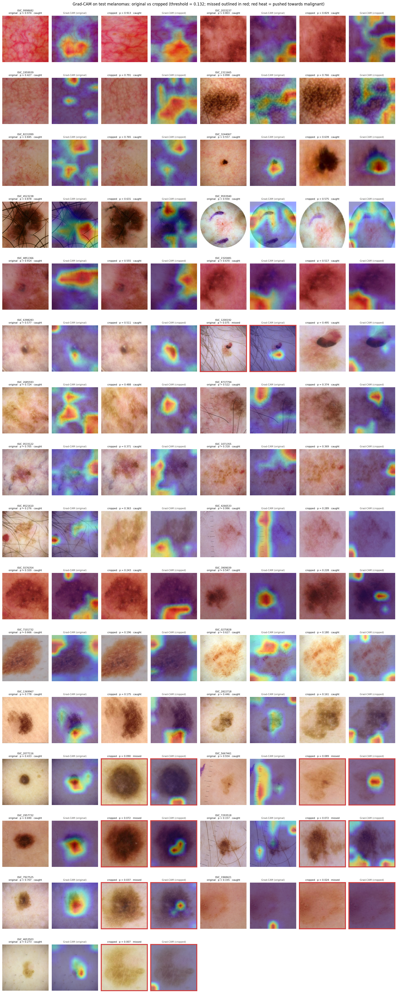

: 

: 

In [64]:
MEL_PER_ROW = 2   # each melanoma = 4 panels (original, Grad-CAM, crop, Grad-CAM) -> 8 columns

mel_both = mel.merge(both[['image_name', 'prob_original']], on='image_name')  # keeps the earlier grids' order

# Sanity check: the replayed head reproduces the model's prediction on an original image too
_, replay_p = gradcam(X_test_orig[name_to_idx[mel_both.loc[0, 'image_name']]])
assert abs(replay_p - mel_both.loc[0, 'prob_original']) < 1e-3, (replay_p, mel_both.loc[0, 'prob_original'])

n_rows = int(np.ceil(len(mel_both) / MEL_PER_ROW))
fig, axes = plt.subplots(n_rows, 4 * MEL_PER_ROW, figsize=(2.2 * 4 * MEL_PER_ROW, 2.8 * n_rows), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')
for k, row in mel_both.iterrows():
    idx = name_to_idx[row['image_name']]
    img_o, img_c = X_test_orig[idx], X_test[idx]
    cam_o, _ = gradcam(img_o)
    cam_c, _ = gradcam(img_c)
    caught_o = row['prob_original'] >= FINAL_THRESHOLD
    caught_c = row['probability'] >= FINAL_THRESHOLD
    panels = [
        (img_o, f"{row['image_name']}\noriginal · p = {row['prob_original']:.3f} · {'caught' if caught_o else 'missed'}", caught_o),
        (overlay(img_o, cam_o), 'Grad-CAM (original)', caught_o),
        (img_c, f"cropped · p = {row['probability']:.3f} · {'caught' if caught_c else 'missed'}", caught_c),
        (overlay(img_c, cam_c), 'Grad-CAM (cropped)', caught_c),
    ]
    r, c0 = k // MEL_PER_ROW, 4 * (k % MEL_PER_ROW)
    for j, (im, title, caught) in enumerate(panels):
        ax = axes[r, c0 + j]
        ax.imshow(im)
        ax.set_title(title, fontsize=7.5, color='#0b0b0b' if j % 2 == 0 else '#52514e')
        if not caught:   # red frame on the version that missed it
            ax.axis('on')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(MISSED_COLOR)
                spine.set_linewidth(3)
fig.suptitle(f'Grad-CAM on test melanomas: original vs cropped (threshold = {FINAL_THRESHOLD:.3f}; '
             f'missed outlined in red; red heat = pushed towards malignant)', fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 1 - 0.6 / fig.get_figheight()))  # leave room for the title on a tall figure

fig.savefig('outputs/resnet_mlp_test_melanomas_gradcam_original_vs_crop.png', dpi=150, bbox_inches='tight', facecolor='white')
if os.path.isdir(DRIVE_DIR):
    shutil.copy('outputs/resnet_mlp_test_melanomas_gradcam_original_vs_crop.png',
                os.path.join(DRIVE_DIR, 'melanoma_outputs', 'resnet_mlp_test_melanomas_gradcam_original_vs_crop.png'))
plt.show()

## 50%-margin test crops on the same model (curiosity check)

Same idea as the original-image section above: the trained `final_model` and `FINAL_THRESHOLD` stay unchanged, and only
the input differs. The test images go through **the same preprocessing as the 0.10 test crops** (DullRazor hair removal →
`crop_with_margin`), but with a **50% margin**, so more skin around the lesion is kept.

How to read it:
- The model was **trained on 0.10 crops**, so 0.50 crops are a mild distribution shift (the lesion is smaller in the frame).
  This shows how the *current* model reacts to wider crops. It's not what a model trained on 0.50 crops would do.
  That question was answered in `crop_margin_cv.ipynb`, which found no real difference between 0.10 and 0.50 when trained on each.
- As before, ROC-AUC / PR-AUC are the fair comparison; the threshold was picked on 0.10 validation crops.
- Descriptive only: don't change the final model based on this, since the test set isn't for choosing settings.

Crops are cached to `test_cropped_margin_0.50/` and `melanoma_test_cropped_margin_0.50.zip` (also on Drive), so reruns
skip the cropping. Needs the test section above (`remove_hair`, `crop_with_margin`, `test_files`, `labelled`, `gradcam`).

In [ ]:
WIDE_MARGIN = 0.50
TEST_WIDE_DIR = f'test_cropped_margin_{WIDE_MARGIN:.2f}'
TEST_WIDE_ZIP = f'melanoma_test_cropped_margin_{WIDE_MARGIN:.2f}.zip'
DRIVE_TEST_WIDE_ZIP = os.path.join('/content/drive/MyDrive', TEST_WIDE_ZIP)

# Restore cached 0.50 test crops (local zip, then Drive), else crop now -- same steps as the 0.10 test crops
os.makedirs(TEST_WIDE_DIR, exist_ok=True)
if not os.listdir(TEST_WIDE_DIR):
    cached_zip = next((z for z in (TEST_WIDE_ZIP, DRIVE_TEST_WIDE_ZIP) if os.path.exists(z)), None)
    if cached_zip:
        with zipfile.ZipFile(cached_zip) as zf:
            zf.extractall(TEST_WIDE_DIR)
        print(f'restored {len(os.listdir(TEST_WIDE_DIR))} test crops from {cached_zip}')
already = set(os.listdir(TEST_WIDE_DIR))
todo = [f for f in test_files if f not in already]
print(f'{len(test_files)} test images, {len(todo)} to preprocess (hair removal + {WIDE_MARGIN:.0%}-margin crop)')

for i, fname in enumerate(todo):
    with Image.open(os.path.join(TEST_DIR, fname)) as img:
        raw = np.array(img.convert('RGB'))
    crop = crop_with_margin(remove_hair(raw), WIDE_MARGIN)
    Image.fromarray(crop).save(os.path.join(TEST_WIDE_DIR, fname))  # same JPEG save as the 0.10 crops
    if (i + 1) % 200 == 0:
        print(f'{i + 1}/{len(todo)} done')

if os.path.isdir('/content/drive/MyDrive') and (todo or not os.path.exists(DRIVE_TEST_WIDE_ZIP)):
    with zipfile.ZipFile(TEST_WIDE_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fname in sorted(os.listdir(TEST_WIDE_DIR)):
            zf.write(os.path.join(TEST_WIDE_DIR, fname), arcname=fname)
    shutil.copy(TEST_WIDE_ZIP, DRIVE_TEST_WIDE_ZIP)
    print(f'saved {len(os.listdir(TEST_WIDE_DIR))} test crops to {DRIVE_TEST_WIDE_ZIP}')

X_test_wide = load_images(test_files, TEST_WIDE_DIR)
print(X_test_wide.shape)

: 

: 

In [ ]:
BENIGN_COLOR, MALIGNANT_COLOR = '#2a78d6', '#eb6834'

test_prob_wide = final_model.predict(make_resnet_dataset(X_test_wide), verbose=0).ravel()
wide_predictions = pd.DataFrame({'image_name': test_names, 'probability': test_prob_wide})
wide_predictions.to_csv('outputs/resnet_mlp_test_margin050_predictions.csv', index=False)
if os.path.isdir(DRIVE_DIR):
    shutil.copy('outputs/resnet_mlp_test_margin050_predictions.csv',
                os.path.join(DRIVE_DIR, 'melanoma_outputs', 'resnet_mlp_test_margin050_predictions.csv'))
print(f'saved outputs/resnet_mlp_test_margin050_predictions.csv ({len(wide_predictions)} rows)')

# One row per test image: 0.10 crop (as trained), 0.50 crop, and the original if that section was run
assert TEST_LABELS_CSV, 'needs the test labels (run the test section above with TEST_LABELS_CSV set)'
three = (labelled[['image_name', 'target', 'probability']].rename(columns={'probability': 'prob_crop'})
         .merge(wide_predictions.rename(columns={'probability': 'prob_wide'}), on='image_name'))
if 'orig_predictions' in globals():
    three = three.merge(orig_predictions.rename(columns={'probability': 'prob_original'}), on='image_name')
y_3 = three['target'].to_numpy().astype(int)

versions_3 = [('0.10 crop (as trained)', 'prob_crop'), ('0.50 crop', 'prob_wide')]
if 'prob_original' in three:
    versions_3.append(('original image', 'prob_original'))

rows = []
for label, col in versions_3:
    p = three[col].to_numpy()
    rows.append({'test images': label, 'ROC-AUC': roc_auc_score(y_3, p), 'PR-AUC': average_precision_score(y_3, p),
                 **metrics_at(y_3, p, FINAL_THRESHOLD), '% flagged': 100 * (p >= FINAL_THRESHOLD).mean(),
                 'median p (benign)': np.median(p[y_3 == 0]), 'median p (melanoma)': np.median(p[y_3 == 1])})
print(f'{len(three)} test images, {y_3.sum()} malignant; threshold = {FINAL_THRESHOLD:.4f} (picked on 0.10 validation crops)')
display(pd.DataFrame(rows).set_index('test images').round(4))

fig, axes = plt.subplots(1, len(versions_3) + 1, figsize=(5.4 * (len(versions_3) + 1), 4.8))
for ax, (label, col) in zip(axes, versions_3):
    pred = (three[col].to_numpy() >= FINAL_THRESHOLD).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_3, pred, labels=[0, 1]),
                           display_labels=['benign', 'malignant']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{label}\n(threshold = {FINAL_THRESHOLD:.3f})', fontsize=10)

# Per-image probability: 0.10 crop vs 0.50 crop
ax = axes[-1]
ben, mal = y_3 == 0, y_3 == 1
ax.scatter(three.loc[ben, 'prob_crop'], three.loc[ben, 'prob_wide'], s=8, alpha=0.35, color=BENIGN_COLOR, label='benign')
ax.scatter(three.loc[mal, 'prob_crop'], three.loc[mal, 'prob_wide'], s=36, alpha=0.9, color=MALIGNANT_COLOR,
           edgecolor='white', linewidth=0.8, label='malignant')
ax.plot([0, 1], [0, 1], color='#a8a7a0', linewidth=1)
ax.axvline(FINAL_THRESHOLD, color='#0b0b0b', linestyle='--', linewidth=1)
ax.axhline(FINAL_THRESHOLD, color='#0b0b0b', linestyle='--', linewidth=1, label='threshold')
ax.set_xlabel('probability on 0.10 crop')
ax.set_ylabel('probability on 0.50 crop')
ax.set_title('Same image, 0.10 vs 0.50 crop')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

: 

: 

### Grad-CAM: 0.50 vs 0.10 crop, on the test melanomas

Same layout as the original-vs-cropped grid: for every test melanoma, **0.50 crop → its Grad-CAM → 0.10 crop → its Grad-CAM**,
in the same order as the earlier grids. A red frame marks the version(s) that missed it at `FINAL_THRESHOLD`. Worth checking
the large lesions that filled the 0.10 crop: does the extra skin at 0.50 move the heat onto the lesion border?
Saved to `outputs/resnet_mlp_test_melanomas_gradcam_margin050_vs_010.png`.

In [ ]:
MEL_PER_ROW = 2   # each melanoma = 4 panels (0.50 crop, Grad-CAM, 0.10 crop, Grad-CAM) -> 8 columns

mel_wide = mel.merge(three[['image_name', 'prob_wide']], on='image_name')  # keeps the earlier grids' order

# Sanity check: the replayed head reproduces the model's prediction on a 0.50 crop too
_, replay_p = gradcam(X_test_wide[name_to_idx[mel_wide.loc[0, 'image_name']]])
assert abs(replay_p - mel_wide.loc[0, 'prob_wide']) < 1e-3, (replay_p, mel_wide.loc[0, 'prob_wide'])

n_rows = int(np.ceil(len(mel_wide) / MEL_PER_ROW))
fig, axes = plt.subplots(n_rows, 4 * MEL_PER_ROW, figsize=(2.2 * 4 * MEL_PER_ROW, 2.8 * n_rows), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')
for k, row in mel_wide.iterrows():
    idx = name_to_idx[row['image_name']]
    img_w, img_c = X_test_wide[idx], X_test[idx]
    cam_w, _ = gradcam(img_w)
    cam_c, _ = gradcam(img_c)
    caught_w = row['prob_wide'] >= FINAL_THRESHOLD
    caught_c = row['probability'] >= FINAL_THRESHOLD
    panels = [
        (img_w, f"{row['image_name']}\n0.50 crop · p = {row['prob_wide']:.3f} · {'caught' if caught_w else 'missed'}", caught_w),
        (overlay(img_w, cam_w), 'Grad-CAM (0.50)', caught_w),
        (img_c, f"0.10 crop · p = {row['probability']:.3f} · {'caught' if caught_c else 'missed'}", caught_c),
        (overlay(img_c, cam_c), 'Grad-CAM (0.10)', caught_c),
    ]
    r, c0 = k // MEL_PER_ROW, 4 * (k % MEL_PER_ROW)
    for j, (im, title, caught) in enumerate(panels):
        ax = axes[r, c0 + j]
        ax.imshow(im)
        ax.set_title(title, fontsize=7.5, color='#0b0b0b' if j % 2 == 0 else '#52514e')
        if not caught:   # red frame on the version that missed it
            ax.axis('on')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(MISSED_COLOR)
                spine.set_linewidth(3)
fig.suptitle(f'Grad-CAM on test melanomas: 0.50 vs 0.10 crop (threshold = {FINAL_THRESHOLD:.3f}; '
             f'missed outlined in red; red heat = pushed towards malignant)', fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 1 - 0.6 / fig.get_figheight()))  # leave room for the title on a tall figure

fig.savefig('outputs/resnet_mlp_test_melanomas_gradcam_margin050_vs_010.png', dpi=150, bbox_inches='tight', facecolor='white')
if os.path.isdir(DRIVE_DIR):
    shutil.copy('outputs/resnet_mlp_test_melanomas_gradcam_margin050_vs_010.png',
                os.path.join(DRIVE_DIR, 'melanoma_outputs', 'resnet_mlp_test_melanomas_gradcam_margin050_vs_010.png'))
plt.show()

: 

: 